In [ ]:
import pandas as pd

In [ ]:
#load file
df = pd.read_csv('/content/twitchdata-update.csv')

In [ ]:
#import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic overview
print(df.shape)
print("\n", df.dtypes)
print("\n", df.head())
print("\n", df.isnull().sum())
print("\n", df.describe())

(1000, 11)

 Channel                 object
Watch time(Minutes)      int64
Stream time(minutes)     int64
Peak viewers             int64
Average viewers          int64
Followers                int64
Followers gained         int64
Views gained             int64
Partnered                 bool
Mature                    bool
Language                object
dtype: object

     Channel  Watch time(Minutes)  Stream time(minutes)  Peak viewers  \
0     xQcOW           6196161750                215250        222720   
1  summit1g           6091677300                211845        310998   
2    Gaules           5644590915                515280        387315   
3  ESL_CSGO           3970318140                517740        300575   
4      Tfue           3671000070                123660        285644   

   Average viewers  Followers  Followers gained  Views gained  Partnered  \
0            27716    3246298           1734810      93036735       True   
1            25610    5310163           13701

In [ ]:
# Feature engineering
df['viewer_retention_rate'] = df['Average viewers'] / df['Peak viewers']
df['followers_per_stream_hour'] = df['Followers gained'] / (df['Stream time(minutes)'] / 60)
df['views_per_follower'] = df['Views gained'] / df['Followers']
df['stream_hours'] = df['Stream time(minutes)'] / 60

# Streamer tier based on followers
df['streamer_tier'] = pd.cut(
    df['Followers'],
    bins=[0, 100000, 500000, 1000000, float('inf')],
    labels=['small', 'mid', 'large', 'mega']
)

print(df['streamer_tier'].value_counts())
print("\n", df[['viewer_retention_rate', 'followers_per_stream_hour', 'views_per_follower']].describe())

streamer_tier
mid      559
large    204
mega     133
small    104
Name: count, dtype: int64

        viewer_retention_rate  followers_per_stream_hour  views_per_follower
count            1000.000000                1000.000000         1000.000000
mean                0.176586                 214.362221           46.220460
std                 0.100768                 599.403079          173.193966
min                 0.006293                  -5.021730            1.061221
25%                 0.099416                  20.544001           11.756722
50%                 0.160473                  57.243064           20.275548
75%                 0.237564                 166.640747           36.480809
max                 0.634687               11772.973312         3002.330048


/tmp/ipykernel_1954/242592158.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='streamer_tier', y='viewer_retention_rate',
/tmp/ipykernel_1954/242592158.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='streamer_tier', y='followers_per_stream_hour',
/tmp/ipykernel_1954/242592158.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='streamer_tier', y='views_per_follower',
/tmp/ipykernel_1954/242592158.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

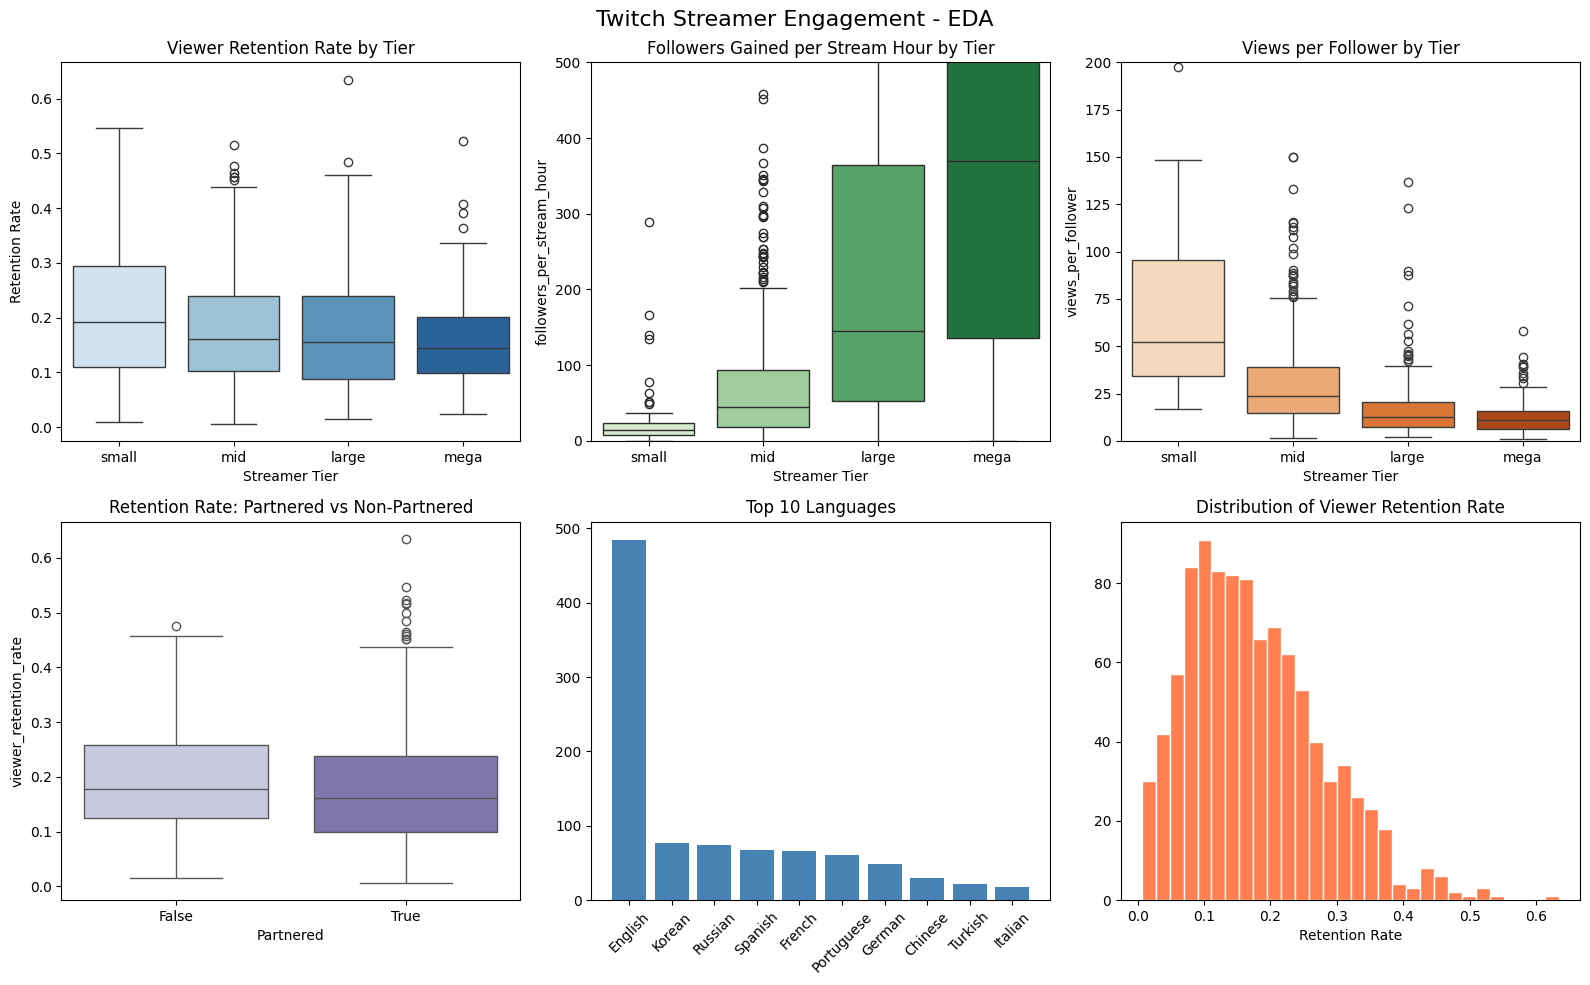

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Twitch Streamer Engagement - EDA', fontsize=16)

# 1. Viewer retention by tier
tier_order = ['small', 'mid', 'large', 'mega']
sns.boxplot(data=df, x='streamer_tier', y='viewer_retention_rate',
            order=tier_order, ax=axes[0,0], palette='Blues')
axes[0,0].set_title('Viewer Retention Rate by Tier')
axes[0,0].set_xlabel('Streamer Tier')
axes[0,0].set_ylabel('Retention Rate')

# 2. Followers gained by tier
sns.boxplot(data=df, x='streamer_tier', y='followers_per_stream_hour',
            order=tier_order, ax=axes[0,1], palette='Greens')
axes[0,1].set_title('Followers Gained per Stream Hour by Tier')
axes[0,1].set_ylim(0, 500)
axes[0,1].set_xlabel('Streamer Tier')

# 3. Views per follower by tier
sns.boxplot(data=df, x='streamer_tier', y='views_per_follower',
            order=tier_order, ax=axes[0,2], palette='Oranges')
axes[0,2].set_title('Views per Follower by Tier')
axes[0,2].set_ylim(0, 200)
axes[0,2].set_xlabel('Streamer Tier')

# 4. Partnered vs retention
sns.boxplot(data=df, x='Partnered', y='viewer_retention_rate',
            ax=axes[1,0], palette='Purples')
axes[1,0].set_title('Retention Rate: Partnered vs Non-Partnered')

# 5. Language distribution (top 10)
top_langs = df['Language'].value_counts().head(10)
axes[1,1].bar(top_langs.index, top_langs.values, color='steelblue')
axes[1,1].set_title('Top 10 Languages')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Retention distribution
axes[1,2].hist(df['viewer_retention_rate'], bins=30, color='coral', edgecolor='white')
axes[1,2].set_title('Distribution of Viewer Retention Rate')
axes[1,2].set_xlabel('Retention Rate')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from scipy import stats
import numpy as np

# Split into two groups
partnered = df[df['Partnered'] == True]['viewer_retention_rate']
non_partnered = df[df['Partnered'] == False]['viewer_retention_rate']

print(f"Partnered streamers: {len(partnered)}")
print(f"Non-partnered streamers: {len(non_partnered)}")
print(f"\nPartnered mean retention: {partnered.mean():.4f}")
print(f"Non-partnered mean retention: {non_partnered.mean():.4f}")
print(f"Observed lift: {((partnered.mean() - non_partnered.mean()) / non_partnered.mean() * 100):.2f}%")

# Two-proportion z-test using retention rate thresholds
threshold = df['viewer_retention_rate'].median()
partnered_high = (partnered > threshold).sum()
non_partnered_high = (non_partnered > threshold).sum()

from statsmodels.stats.proportion import proportions_ztest
count = np.array([partnered_high, non_partnered_high])
nobs = np.array([len(partnered), len(non_partnered)])
stat, pval = proportions_ztest(count, nobs)

print(f"\nZ-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")
print(f"Significant at 95% confidence: {pval < 0.05}")

# Bootstrapped confidence intervals
np.random.seed(42)
boot_diffs = []
for _ in range(10000):
    boot_p = np.random.choice(partnered, size=len(partnered), replace=True).mean()
    boot_np = np.random.choice(non_partnered, size=len(non_partnered), replace=True).mean()
    boot_diffs.append(boot_p - boot_np)

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
print(f"\n95% Bootstrap CI for difference in retention: [{ci_lower:.4f}, {ci_upper:.4f}]")

Partnered streamers: 978
Non-partnered streamers: 22

Partnered mean retention: 0.1761
Non-partnered mean retention: 0.1990
Observed lift: -11.51%

Z-statistic: -0.4312
P-value: 0.6663
Significant at 95% confidence: False

95% Bootstrap CI for difference in retention: [-0.0732, 0.0227]


In [ ]:
mature = df[df['Mature'] == True]['viewer_retention_rate']
non_mature = df[df['Mature'] == False]['viewer_retention_rate']

print(f"Mature streamers: {len(mature)}")
print(f"Non-mature streamers: {len(non_mature)}")
print(f"\nMature mean retention: {mature.mean():.4f}")
print(f"Non-mature mean retention: {non_mature.mean():.4f}")
print(f"Observed lift: {((mature.mean() - non_mature.mean()) / non_mature.mean() * 100):.2f}%")

# Two-proportion z-test
threshold = df['viewer_retention_rate'].median()
mature_high = (mature > threshold).sum()
non_mature_high = (non_mature > threshold).sum()

from statsmodels.stats.proportion import proportions_ztest
import numpy as np

count = np.array([mature_high, non_mature_high])
nobs = np.array([len(mature), len(non_mature)])
stat, pval = proportions_ztest(count, nobs)

print(f"\nZ-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")
print(f"Significant at 95% confidence: {pval < 0.05}")

# Bootstrapped confidence intervals
np.random.seed(42)
boot_diffs = []
for _ in range(10000):
    boot_m = np.random.choice(mature, size=len(mature), replace=True).mean()
    boot_nm = np.random.choice(non_mature, size=len(non_mature), replace=True).mean()
    boot_diffs.append(boot_m - boot_nm)

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
print(f"\n95% Bootstrap CI for difference in retention: [{ci_lower:.4f}, {ci_upper:.4f}]")

Mature streamers: 230
Non-mature streamers: 770

Mature mean retention: 0.1874
Non-mature mean retention: 0.1733
Observed lift: 8.13%

Z-statistic: 1.8034
P-value: 0.0713
Significant at 95% confidence: False

95% Bootstrap CI for difference in retention: [-0.0010, 0.0296]


small: mature=0.1835, non-mature=0.2036, lift=-9.87%, n_mature=28, n_non=76
mid: mature=0.1931, non-mature=0.1736, lift=11.22%, n_mature=140, n_non=419
large: mature=0.1890, non-mature=0.1680, lift=12.47%, n_mature=43, n_non=161
mega: mature=0.1482, non-mature=0.1598, lift=-7.27%, n_mature=19, n_non=114


/tmp/ipykernel_1954/1117907608.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_mature = df.groupby(['streamer_tier', 'Mature'])['viewer_retention_rate'].mean().unstack()


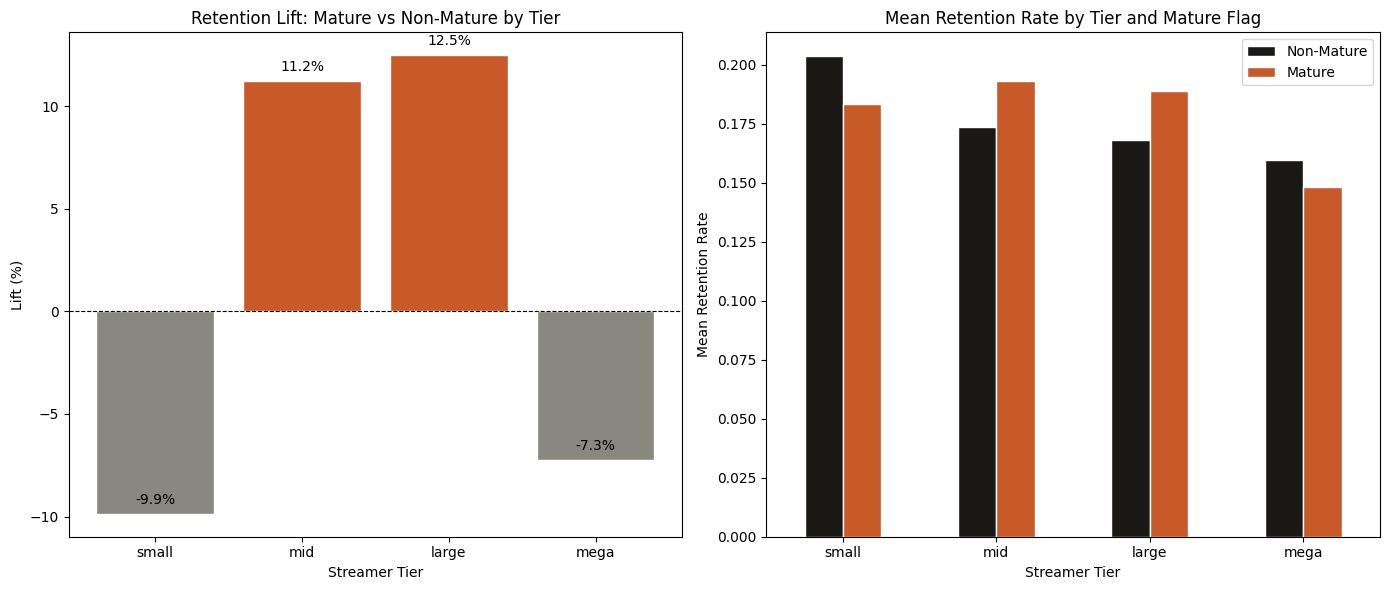

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Retention lift by tier: mature vs non-mature
tier_order = ['small', 'mid', 'large', 'mega']
lift_by_tier = []

for tier in tier_order:
    tier_df = df[df['streamer_tier'] == tier]
    m = tier_df[tier_df['Mature'] == True]['viewer_retention_rate'].mean()
    nm = tier_df[tier_df['Mature'] == False]['viewer_retention_rate'].mean()
    lift = (m - nm) / nm * 100 if nm > 0 else 0
    n_mature = len(tier_df[tier_df['Mature'] == True])
    n_non_mature = len(tier_df[tier_df['Mature'] == False])
    lift_by_tier.append({'tier': tier, 'lift': lift, 'n_mature': n_mature, 'n_non': n_non_mature})
    print(f"{tier}: mature={m:.4f}, non-mature={nm:.4f}, lift={lift:.2f}%, n_mature={n_mature}, n_non={n_non_mature}")

lift_df = pd.DataFrame(lift_by_tier)

# Plot 1: Lift by tier
colors = ['#c85a2a' if x > 0 else '#888780' for x in lift_df['lift']]
axes[0].bar(lift_df['tier'], lift_df['lift'], color=colors, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Retention Lift: Mature vs Non-Mature by Tier')
axes[0].set_xlabel('Streamer Tier')
axes[0].set_ylabel('Lift (%)')
for i, row in lift_df.iterrows():
    axes[0].text(i, row['lift'] + 0.5, f"{row['lift']:.1f}%", ha='center', fontsize=10)

# Plot 2: Retention rate by tier and mature flag
tier_mature = df.groupby(['streamer_tier', 'Mature'])['viewer_retention_rate'].mean().unstack()
tier_mature = tier_mature.reindex(tier_order)
tier_mature.plot(kind='bar', ax=axes[1], color=['#1a1814', '#c85a2a'], edgecolor='white')
axes[1].set_title('Mean Retention Rate by Tier and Mature Flag')
axes[1].set_xlabel('Streamer Tier')
axes[1].set_ylabel('Mean Retention Rate')
axes[1].legend(['Non-Mature', 'Mature'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('ab_test_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()